<a href="https://colab.research.google.com/github/rinviriti/AI-ML-Learning-Journey/blob/main/11_medical_ai/grad_cam_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grad-CAM Basics for Explainable AI

Grad-CAM stands for Gradient-weighted Class Activation Mapping.

It is an Explainable AI technique used to understand which parts of an image influenced a CNN model's prediction.

In Medical AI, Grad-CAM can help show whether a model is focusing on the correct medical region.

Examples:

- Skin lesion area
- Tumor region in MRI
- Lung infection region in X-ray

## Learning Objectives

- Understand what Grad-CAM is
- Load a pre-trained CNN model
- Make image predictions
- Generate a heatmap
- Overlay the heatmap on the original image

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from skimage import data

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Step 1: Load a Pre-trained CNN Model

We will use MobileNetV2.

MobileNetV2 is a lightweight CNN model trained on ImageNet.

It can recognize many everyday objects and is useful for learning explainability techniques.

In [2]:
model = MobileNetV2(weights="imagenet")

model.summary()

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Step 2: Load a Sample Image

To make this notebook easy to run, we will use a built-in sample image.

In real Medical AI projects, this image could be a skin lesion, MRI, X-ray, or CT image.

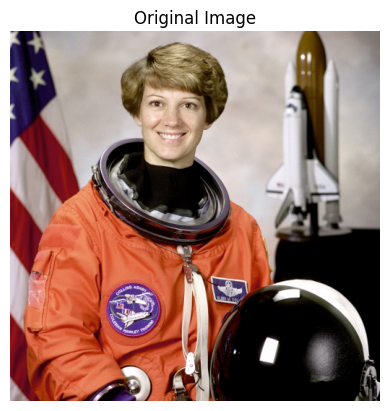

In [3]:
sample_image = data.astronaut()

plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Step 3: Preprocess the Image

MobileNetV2 requires images to be:

- Resized to 224 × 224
- Converted into a NumPy array
- Expanded into batch format
- Preprocessed using MobileNetV2 preprocessing

In [4]:
img_resized = cv2.resize(sample_image, (224, 224))

img_array = np.expand_dims(img_resized, axis=0)

img_preprocessed = preprocess_input(img_array)

## Step 4: Make Prediction

The model predicts what object is present in the image.

Although this is not a medical image, the same Grad-CAM concept applies to medical images.

In [5]:
predictions = model.predict(img_preprocessed)

decoded_predictions = decode_predictions(predictions, top=3)[0]

for pred in decoded_predictions:
    print(pred[1], ":", pred[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
jersey : 0.060093388
football_helmet : 0.057907846
bassoon : 0.055781495


## Step 5: Select the Last Convolution Layer

Grad-CAM uses the final convolution layer because it contains important spatial information.

For MobileNetV2, we can use:

`Conv_1`

In [6]:
last_conv_layer_name = "Conv_1"

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.output
    ]
)

## Step 6: Compute Gradients

Grad-CAM calculates how strongly each feature map contributed to the predicted class.

This helps identify the regions that influenced the model's decision.

In [7]:
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_preprocessed)

    predicted_class = tf.argmax(predictions[0])

    class_output = predictions[:, predicted_class]

grads = tape.gradient(class_output, conv_outputs)

## Step 7: Generate the Grad-CAM Heatmap

The heatmap shows which areas of the image were most important for the model's prediction.

Warmer regions usually indicate stronger model attention.

In [8]:
pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)

heatmap = heatmap / tf.math.reduce_max(heatmap)

heatmap = heatmap.numpy()

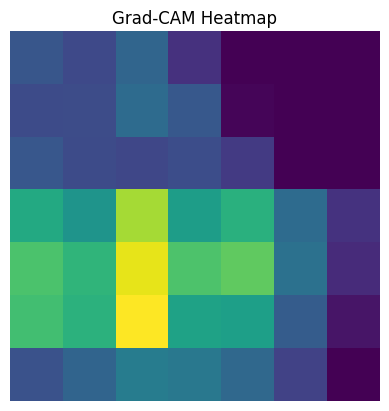

In [9]:
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

## Step 8: Overlay Heatmap on Original Image

To better interpret Grad-CAM, we overlay the heatmap on the original image.

This allows us to visually inspect what part of the image influenced the prediction.

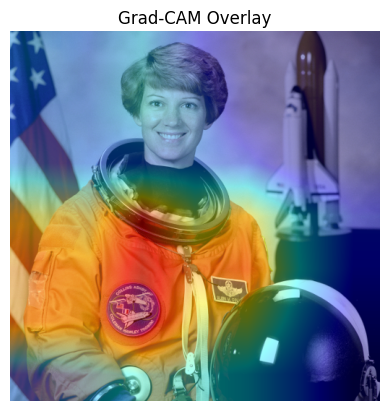

In [10]:
heatmap_resized = cv2.resize(
    heatmap,
    (sample_image.shape[1], sample_image.shape[0])
)

heatmap_colored = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)

heatmap_colored = cv2.cvtColor(
    heatmap_colored,
    cv2.COLOR_BGR2RGB
)

overlay = cv2.addWeighted(
    sample_image,
    0.6,
    heatmap_colored,
    0.4,
    0
)

plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()

## Step 9: Interpretation

The highlighted regions show which image areas were important for the model's prediction.

In Medical AI, this can help answer questions such as:

- Did the model focus on the lesion?
- Did the model focus on the tumor area?
- Did the model focus on irrelevant background?
- Can a clinician understand the model's reasoning?

Grad-CAM does not prove that the model is correct, but it improves transparency.

# Conclusion

In this notebook, we learned the basics of Grad-CAM.

## What I Learned

- What Grad-CAM is
- Why Grad-CAM is useful in Explainable AI
- How to load a pre-trained CNN model
- How to generate a heatmap
- How to overlay the heatmap on an image
- Why Grad-CAM is important for Medical AI and MobileSkinXAI

Grad-CAM is one of the most useful explainability techniques for image-based healthcare AI systems.